# Исследование линейной регрессии на датасете Toyota Corolla
### исходники датасета --> [тута](https://www.kaggle.com/datasets/nameeerafatima/toyotacsv)

In [27]:
import warnings;
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## 1) Первичный анализ и очистка данных

In [28]:
df = pd.read_csv('./Toyota.csv')

print(f"размер датасета --> {df.shape}")

df = df.drop(columns="Unnamed: 0")
df.head()

размер датасета --> (1436, 11)


,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986,Diesel,90,1.0,0,2000,three,1165
1,13750,23.0,72937,Diesel,90,1.0,0,2000,3,1165
2,13950,24.0,41711,Diesel,90,NaN,0,2000,3,1165
3,14950,26.0,48000,Diesel,90,0.0,0,2000,3,1165
4,13750,30.0,38500,Diesel,90,0.0,0,2000,3,1170


In [29]:
# статистика по фрейму
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1436 non-null   int64  
 1   Age        1336 non-null   float64
 2   KM         1436 non-null   str    
 3   FuelType   1336 non-null   str    
 4   HP         1436 non-null   str    
 5   MetColor   1286 non-null   float64
 6   Automatic  1436 non-null   int64  
 7   CC         1436 non-null   int64  
 8   Doors      1436 non-null   str    
 9   Weight     1436 non-null   int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 112.3 KB
None


In [30]:
print(f"\nСтатистика : \n {df.describe()}")


Статистика : 
               Price          Age     MetColor    Automatic           CC  \
count   1436.000000  1336.000000  1286.000000  1436.000000  1436.000000   
mean   10730.824513    55.672156     0.674961     0.055710  1566.827994   
std     3626.964585    18.589804     0.468572     0.229441   187.182436   
min     4350.000000     1.000000     0.000000     0.000000  1300.000000   
25%     8450.000000    43.000000     0.000000     0.000000  1400.000000   
50%     9900.000000    60.000000     1.000000     0.000000  1600.000000   
75%    11950.000000    70.000000     1.000000     0.000000  1600.000000   
max    32500.000000    80.000000     1.000000     1.000000  2000.000000   

           Weight  
count  1436.00000  
mean   1072.45961  
std      52.64112  
min    1000.00000  
25%    1040.00000  
50%    1070.00000  
75%    1085.00000  
max    1615.00000  


In [31]:
print(f"\nПропуски : \n {df.isnull().sum()}")


Пропуски : 
 Price          0
Age          100
KM             0
FuelType     100
HP             0
MetColor     150
Automatic      0
CC             0
Doors          0
Weight         0
dtype: int64


In [32]:
#проверяем категориальные колонки на mixed values
obj_cols = df.select_dtypes(include='object').columns

# ищем число конвертируемых в число к общему числу и сами поломанные значения
for col in obj_cols:
    print("\n",col)
    converted = pd.to_numeric(df[col],errors="coerce")
    total = df[col].notna().sum()
    ok = converted.notna().sum()
    print(f"соотношение конвертируемых в число к общему числу --> {ok}/{total}")
    print("\n Не валидные значения :")
    
    bad_mask = converted.isna() & df[col].notna()
    bad_value = df.loc[bad_mask,col]
    
    print(col)
    print(bad_value)


 KM
соотношение конвертируемых в число к общему числу --> 1421/1436

 Не валидные значения :
KM
6       ??
64      ??
91      ??
112     ??
125     ??
131     ??
398     ??
491     ??
1049    ??
1120    ??
1421    ??
1425    ??
1428    ??
1432    ??
1434    ??
Name: KM, dtype: str

 FuelType
соотношение конвертируемых в число к общему числу --> 0/1336

 Не валидные значения :
FuelType
0       Diesel
1       Diesel
2       Diesel
3       Diesel
4       Diesel
         ...  
1430    Petrol
1431    Petrol
1432    Petrol
1433    Petrol
1435    Petrol
Name: FuelType, Length: 1336, dtype: str

 HP
соотношение конвертируемых в число к общему числу --> 1430/1436

 Не валидные значения :
HP
6       ????
9       ????
15      ????
631     ????
638     ????
1245    ????
Name: HP, dtype: str

 Doors
соотношение конвертируемых в число к общему числу --> 1433/1436

 Не валидные значения :
Doors
0      three
167     four
324     five
Name: Doors, dtype: str


По коду выше видно, что колонки с типом string в основном были строкой из-за некоторых битых токенов, колонка FuelType как категориальная ок, после того как были определены поломанные значения их можно заменить на опр значения

In [33]:
# чистим пробелы
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

df = df.replace({
    "nan": np.nan,
    "None": np.nan,
    "": np.nan,
    "??": np.nan,
    "????": np.nan
})

# фиксим Doors
df["Doors"] = df["Doors"].replace({
    "three": 3,
    "four": 4,
    "five": 5,
    "3": 3,
    "4": 4,
    "5": 5
})

# приводим нужные колонки к numeric
numeric_cols = ["Price", "Age", "KM", "HP", "MetColor", "Automatic", "CC", "Doors", "Weight"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)
print(df.isnull().sum())

Price          int64
Age          float64
KM           float64
FuelType         str
HP           float64
MetColor     float64
Automatic      int64
CC             int64
Doors          int64
Weight         int64
dtype: object
Price          0
Age          100
KM            15
FuelType     100
HP             6
MetColor     150
Automatic      0
CC             0
Doors          0
Weight         0
dtype: int64


## 2) EDA


In [34]:
print(df.describe(include="all"))

               Price          Age             KM FuelType           HP  \
count    1436.000000  1336.000000    1421.000000     1336  1430.000000   
unique           NaN          NaN            NaN        3          NaN   
top              NaN          NaN            NaN   Petrol          NaN   
freq             NaN          NaN            NaN     1177          NaN   
mean    10730.824513    55.672156   68647.239972      NaN   101.478322   
std      3626.964585    18.589804   37333.023589      NaN    14.768255   
min      4350.000000     1.000000       1.000000      NaN    69.000000   
25%      8450.000000    43.000000   43210.000000      NaN    90.000000   
50%      9900.000000    60.000000   63634.000000      NaN   110.000000   
75%     11950.000000    70.000000   87000.000000      NaN   110.000000   
max     32500.000000    80.000000  243000.000000      NaN   192.000000   

           MetColor    Automatic           CC        Doors      Weight  
count   1286.000000  1436.000000  1436

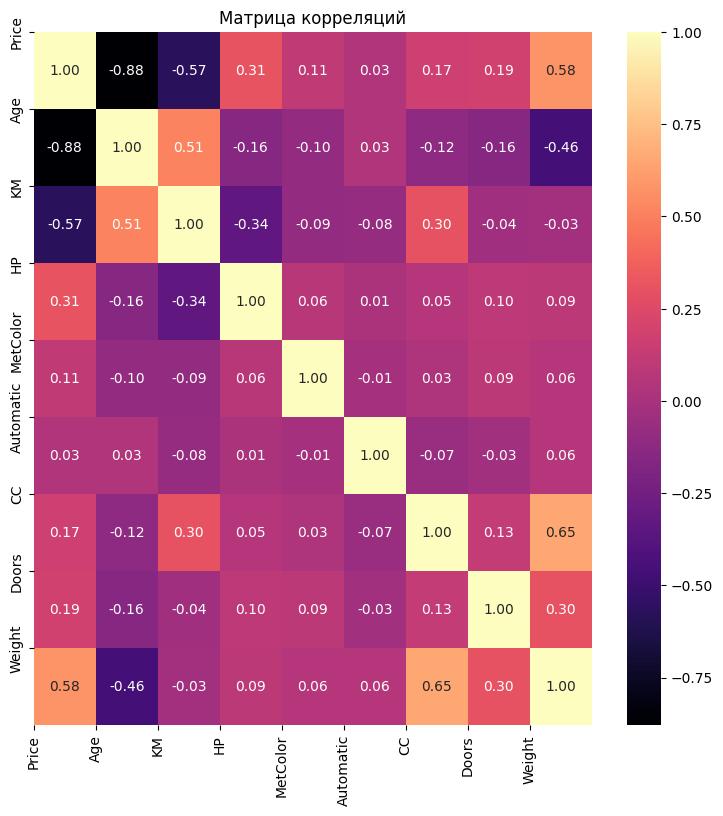

In [35]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

По матрице довольно хорошо видно корреляцию между ценой и весом/километрожом/возрастом + также просвечивается связь между Age и KM

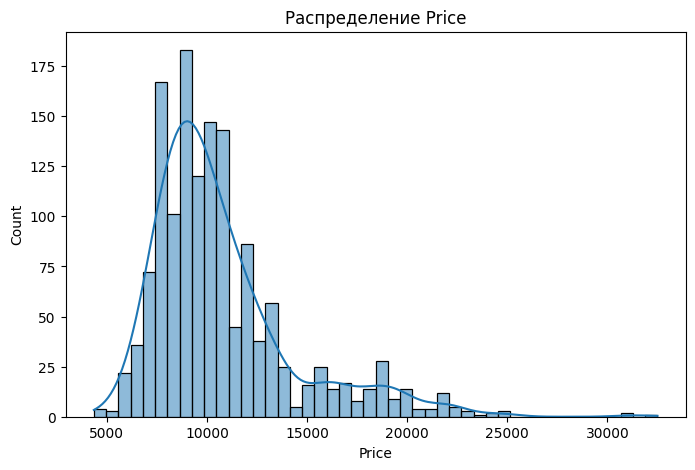

In [36]:
#гисторама + kde для прайса
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], kde=True)
plt.title("Распределение Price")
plt.show()

В среденем видно что прайс крутится в диапазоне 10000, что отражает гистограма с kde

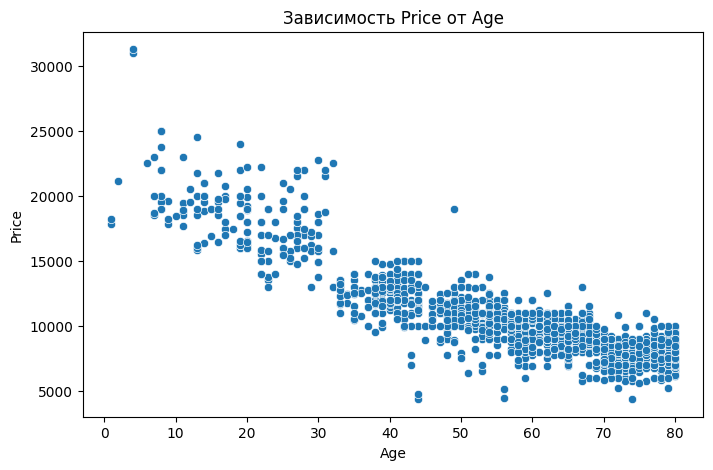

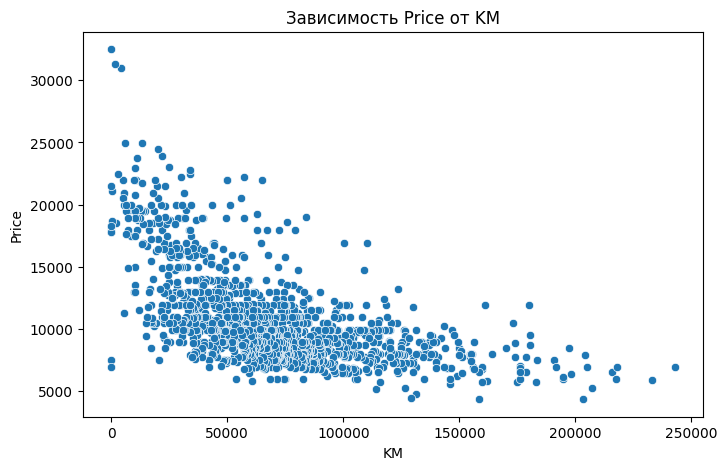

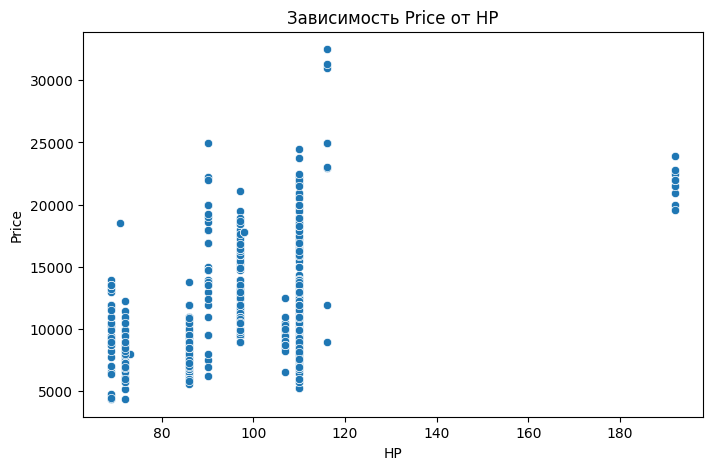

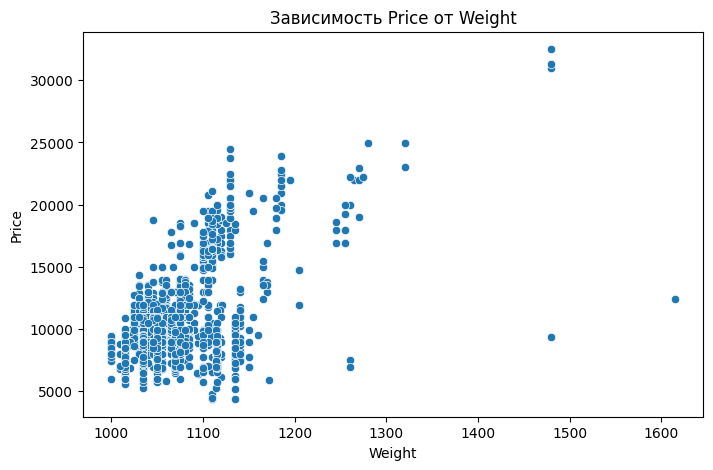

In [37]:
#scatterplots под основные категории
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Price")
plt.title("Зависимость Price от Age")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="KM", y="Price")
plt.title("Зависимость Price от KM")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="HP", y="Price")
plt.title("Зависимость Price от HP")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Weight", y="Price")
plt.title("Зависимость Price от Weight")
plt.show()

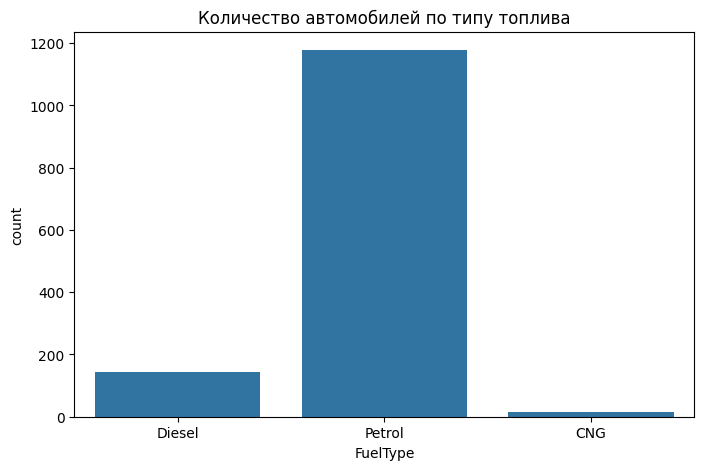

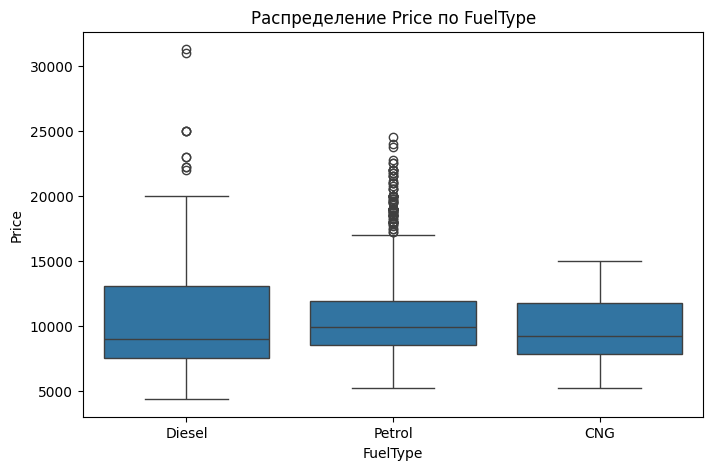

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="FuelType")
plt.title("Количество автомобилей по типу топлива")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="FuelType", y="Price")
plt.title("Распределение Price по FuelType")
plt.show()

После EDA анализа очень заметно на сколько сильно коррелируют цена с возрастом/пробегом и весом. В среднем больше легких по весу автомобилей и по столбчатой диаграеме видно, что по типу топлива безусловно выигрывают бензиновые


## 3) Feature engineering

In [39]:
df["KM_per_Age"] = df["KM"] / df["Age"]
df["KM_per_Age"] = df["KM_per_Age"].replace([np.inf, -np.inf], np.nan)

#One-Hot encoding
df = pd.get_dummies(df, columns=["FuelType"],drop_first=True) 
df.head()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight,KM_per_Age,FuelType_Diesel,FuelType_Petrol
0,13500,23.0,46986.0,90.0,1.0,0,2000,3,1165,2042.869565,True,False
1,13750,23.0,72937.0,90.0,1.0,0,2000,3,1165,3171.173913,True,False
2,13950,24.0,41711.0,90.0,NaN,0,2000,3,1165,1737.958333,True,False
3,14950,26.0,48000.0,90.0,0.0,0,2000,3,1165,1846.153846,True,False
4,13750,30.0,38500.0,90.0,0.0,0,2000,3,1170,1283.333333,True,False


был сделан one-hot encoding для типа топлива + ввел новую фичу пробега

## 4) Разделение выборки

In [40]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [41]:
# разделение датасета на обучающую и тестовую выборку
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1148, 11)
X_test: (288, 11)
y_train: (1148,)
y_test: (288,)


Разделил выборку на train/test, validation не вводил тк не вижу целесообразности для линейной, подбор оптимальной лямбды идет через кросс-валидацию.
Ответ на вопрос почему нельзя обучать и проверять модель на одном и том же наборе: 

если так делать то можно словить переобучение -- ситуация, когда модель идеально подберет веса на трейне просто потому что выучит и подстроится под них, но в реале они будут не оптимальными

## 5) Обучение моделей

In [42]:
#функция с метриками
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    result = {
        "Model": name,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

    print(f"\n {name} ")
    print(f"Train RMSE: {train_rmse}")
    print(f"Test RMSE:  {test_rmse} \n")
    print(f"Train MAE:  {train_mae}")
    print(f"Test MAE:   {test_mae} \n")
    print(f"Train R2:   {train_r2}")
    print(f"Test R2:    {test_r2}")

    return result

In [43]:
#базовый пайплайн
preprocessor = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaller",StandardScaler())
])

In [44]:
# учим базову модельку
lr_base = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

lr_base.fit(X_train,y_train)

lr_res = evaluate_model("LinearRegression",lr_base,X_train,X_test,y_train,y_test)



 LinearRegression 
Train RMSE: 1429.4792450263183
Test RMSE:  1618.4245106749781 

Train MAE:  1009.5204168356673
Test MAE:   1013.7229205685767 

Train R2:   0.8439369988640409
Test R2:    0.8036918722587794


In [45]:
# с ridge регуляризацией
ridge_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",Ridge())
])

ridge_params = {"model__alpha":[0.01,0.1,1,10,100]}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train,y_train)

print(f"Лучший шаг для Ridge : {ridge_grid.best_params_}")
print("Лучшая метрика :", -ridge_grid.best_score_)

ridge_result = evaluate_model(
    "Ridge",
    ridge_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)


Лучший шаг для Ridge : {'model__alpha': 100}
Лучшая метрика : 1492.9297908071715

 Ridge 
Train RMSE: 1446.1753836083751
Test RMSE:  1561.1654970896946 

Train MAE:  1026.6182343061205
Test MAE:   1029.6205936871588 

Train R2:   0.8402701162093618
Test R2:    0.8173367098997621


In [46]:
# с lasso регуляризацией
lasso_pipeline =Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model", Lasso(max_iter=10000))
])

lasso_params = {
    "model__alpha":[0.001,0.01,0.1,1,10]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train,y_train)

print(f"Лучший шаг для Lasso : {lasso_grid.best_params_}")
print("Лучшая метрика :", -lasso_grid.best_score_)

lasso_res = evaluate_model("Lasso",lasso_grid.best_estimator_,X_train,X_test,y_train,y_test)

Лучший шаг для Lasso : {'model__alpha': 10}
Лучшая метрика : 1494.9309336492624

 Lasso 
Train RMSE: 1429.980612290603
Test RMSE:  1604.1130960054127 

Train MAE:  1010.9256793315492
Test MAE:   1015.3649743333467 

Train R2:   0.8438275064012637
Test R2:    0.8071483514489781


In [47]:
results_df = pd.DataFrame([lr_res, ridge_result, lasso_res])
results_df = results_df.sort_values(by="Test RMSE")
results_df

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
1,Ridge,1446.175384,1561.165497,1026.618234,1029.620594,0.840270,0.817337
2,Lasso,1429.980612,1604.113096,1010.925679,1015.364974,0.843828,0.807148
0,LinearRegression,1429.479245,1618.424511,1009.520417,1013.722921,0.843937,0.803692


По результатам:

На текущем датасете для линейной регресии все три модели показали относительно хорошие показатели, на трех держится кэф детерминации выше 0.8, RMSE и MAE не особо сильно расходятся. Как вывод модели относительно стабильны, на будущее можно будет поработать чуть более качественнее с признаками, на датасете с 11 колонками можно выдать ну МАКСИМУМ 0.8 кэф детерминации, дальше надо скейлить признаки и улучшать предобработку. Эт слово к тому на сколько важно для линейной хорошо обрабатывать данные)

## 6) Оценка качества и сравнение моделей

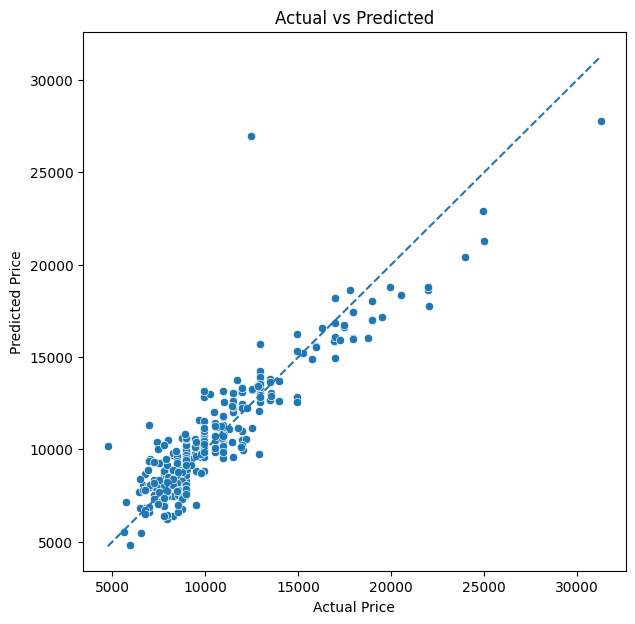

In [ ]:
## строим prediction error plot для лучшей модели по метрикам

#ridge регуляризация
best_model_ridge = ridge_grid.best_estimator_ 
y_test_pred = best_model_ridge.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

В табличке выше по метрикам лучше всех себя показала ridge регулеризация, по значениям у нее лучший RMSE и кэф детерминации

По метрикам:
1) RMSE(root mean squared error), MSE не брал на текущем датасете ошибка в квадрате довольно большая и настолькоже не информативная, RMSE помогает более объективно оценить
2) MAE(mean absolute error), помогает посмотреть в среднем на промах в метриках, RMSE к ошибкам довольно чувствительна, поэтому я юзаю их в связке чтобы смотреть на разницу, у меня она еще терпимая, следовательно моделька ошибается из-за наличия выбросов, но не прям по крупному
3) R^2 (коэффицент детерминации), помогает сделать относительную оценку, в данной метрики стремимя к 1

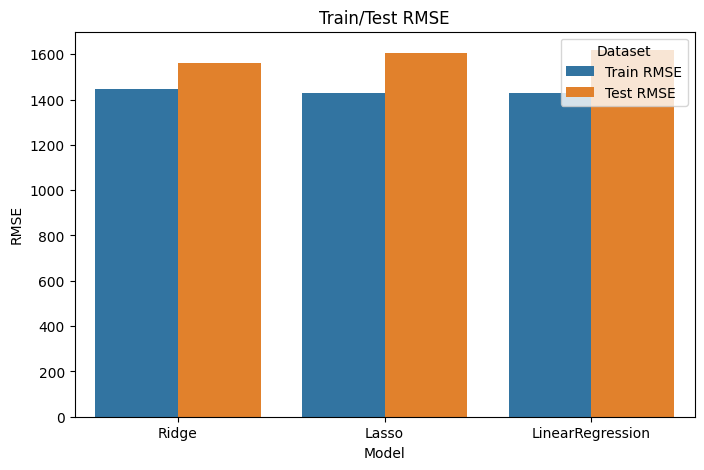

In [49]:
rmse_df = results_df[["Model", "Train RMSE", "Test RMSE"]].melt(
    id_vars="Model", var_name="Dataset", value_name="RMSE"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=rmse_df, x="Model", y="RMSE", hue="Dataset")
plt.title("Train/Test RMSE")
plt.show()

Про вопрос overfitting/underfitting

Специально для этого вывел столбчатую диаграмму, по ней видно что в среднем значения не особо расходятся на трейне и тесте, следовательно модель не переобучилась.
